Enter source node: A
Enter destination node: E

Shortest Path: ['A', 'C', 'B', 'D', 'E']
Distance: 10


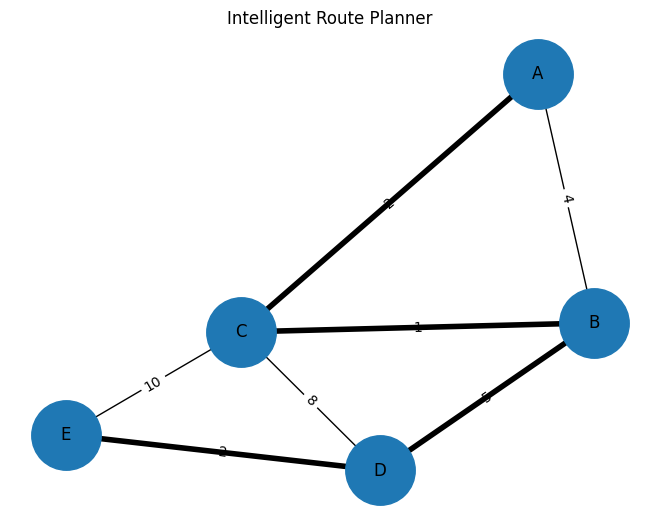

In [ ]:
# Install required libraries
!pip install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
import heapq

# -------------------------
# Create Graph
# -------------------------

graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'A': 4, 'C': 1, 'D': 5},
    'C': {'A': 2, 'B': 1, 'D': 8, 'E': 10},
    'D': {'B': 5, 'C': 8, 'E': 2},
    'E': {'C': 10, 'D': 2}
}

# -------------------------
# Dijkstra Algorithm
# -------------------------

def dijkstra(graph, start, end):

    pq = [(0, start)]
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {}

    while pq:
        current_distance, current_node = heapq.heappop(pq)

        if current_node == end:
            break

        for neighbor, weight in graph[current_node].items():

            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(
                    pq,
                    (distance, neighbor)
                )

    path = []
    node = end

    while node in previous:
        path.append(node)
        node = previous[node]

    path.append(start)
    path.reverse()

    return path, distances[end]

# -------------------------
# User Input
# -------------------------

source = input("Enter source node: ")
destination = input("Enter destination node: ")

path, distance = dijkstra(
    graph,
    source,
    destination
)

print("\nShortest Path:", path)
print("Distance:", distance)

# -------------------------
# Visualization
# -------------------------

G = nx.Graph()

for node in graph:
    for neighbor, weight in graph[node].items():
        G.add_edge(
            node,
            neighbor,
            weight=weight
        )

pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500
)

edge_labels = nx.get_edge_attributes(
    G,
    'weight'
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

path_edges = list(
    zip(path, path[1:])
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    width=4
)

plt.title("Intelligent Route Planner")
plt.show()


In [ ]:
from collections import deque

def bfs(graph, start, end):

    queue = deque([(start, [start])])

    visited = set()

    while queue:

        node, path = queue.popleft()

        if node == end:
            return path

        if node not in visited:

            visited.add(node)

            for neighbor in graph[node]:

                queue.append(
                    (neighbor, path + [neighbor])
                )

    return []

In [ ]:
def dfs(graph, start, end):

    stack = [(start, [start])]

    visited = set()

    while stack:

        node, path = stack.pop()

        if node == end:
            return path

        if node not in visited:

            visited.add(node)

            for neighbor in graph[node]:

                stack.append(
                    (neighbor, path + [neighbor])
                )

    return []

In [ ]:
import time

# Dijkstra timing
start = time.time()

dijkstra_path, dijkstra_dist = dijkstra(
    graph,
    source,
    destination
)

dijkstra_time = time.time() - start

# BFS timing
start = time.time()

bfs_path = bfs(
    graph,
    source,
    destination
)

bfs_time = time.time() - start

# DFS timing
start = time.time()

dfs_path = dfs(
    graph,
    source,
    destination
)

dfs_time = time.time() - start

print("------ RESULTS ------")

print("\nDijkstra")
print("Path:", dijkstra_path)
print("Distance:", dijkstra_dist)
print("Time:", dijkstra_time)

print("\nBFS")
print("Path:", bfs_path)
print("Time:", bfs_time)

print("\nDFS")
print("Path:", dfs_path)
print("Time:", dfs_time)

------ RESULTS ------

Dijkstra
Path: ['A', 'C', 'B', 'D', 'E']
Distance: 10
Time: 0.00012826919555664062

BFS
Path: ['A', 'C', 'E']
Time: 9.274482727050781e-05

DFS
Path: ['A', 'C', 'E']
Time: 7.677078247070312e-05


In [ ]:
total_nodes = len(graph)

total_edges = sum(
    len(graph[node])
    for node in graph
) // 2

print("\nPROJECT METRICS")

print("Nodes:", total_nodes)

print("Edges:", total_edges)

print("Algorithms Used: 3")

print("Route Found:", len(path))


PROJECT METRICS
Nodes: 5
Edges: 7
Algorithms Used: 3
Route Found: 5


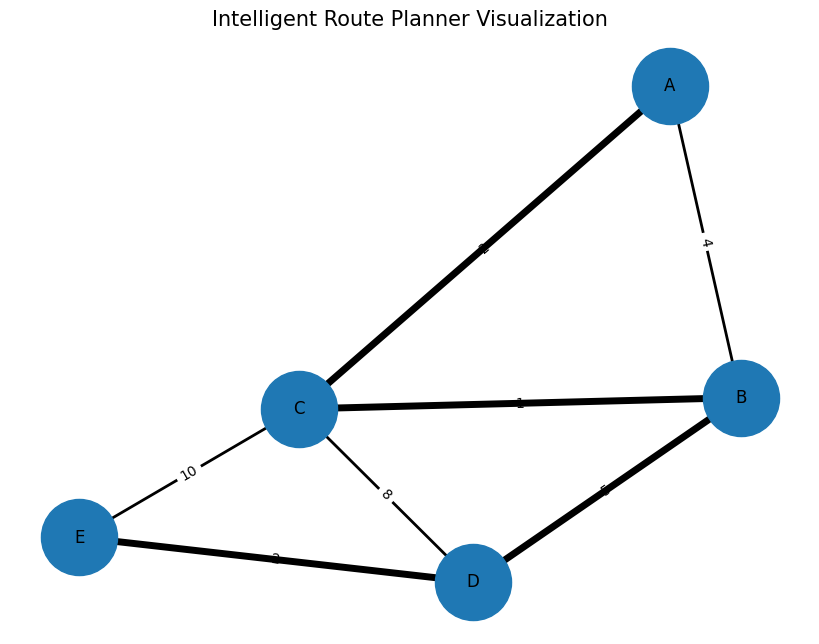

In [ ]:
plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    width=2
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    width=5
)

plt.title(
    "Intelligent Route Planner Visualization",
    fontsize=15
)

plt.show()

In [ ]:
def alternative_routes(graph, start):

    print("\nAvailable Connections:")

    for neighbor in graph[start]:

        print(
            start,
            "->",
            neighbor,
            "Distance:",
            graph[start][neighbor]
        )

alternative_routes(
    graph,
    source
)


Available Connections:
A -> B Distance: 4
A -> C Distance: 2


In [ ]:
if distance <= 5:

    category = "Short Route"

elif distance <= 10:

    category = "Medium Route"

else:

    category = "Long Route"

print(
    "\nRoute Category:",
    category
)



Route Category: Medium Route


In [ ]:
import pandas as pd

result = pd.DataFrame({

    "Source":[source],

    "Destination":[destination],

    "Shortest_Path":[str(path)],

    "Distance":[distance]

})

result.to_csv(

    "route_results.csv",

    index=False

)

print(

    "\nCSV File Saved"

)


CSV File Saved


In [ ]:
traffic_multiplier = 1.2

traffic_distance = distance * traffic_multiplier

print(

    "\nEstimated Distance with Traffic:",

    round(

        traffic_distance,

        2

    )

)


Estimated Distance with Traffic: 12.0


In [ ]:
import random

closed_node = random.choice(

    list(graph.keys())

)

print(

    "\nRoad Closed Near:",

    closed_node

)


Road Closed Near: B


In [ ]:
print("\n------ ROUTE SUMMARY ------")

print(

    "Start:",

    source

)

print(

    "Destination:",

    destination

)

print(

    "Path:",

    " -> ".join(path)

)

print(

    "Distance:",

    distance

)

print(

    "Nodes Visited:",

    len(path)

)


------ ROUTE SUMMARY ------
Start: A
Destination: E
Path: A -> C -> B -> D -> E
Distance: 10
Nodes Visited: 5


In [ ]:
graph = {

"Pune":{"Mumbai":150,"Nashik":210},

"Mumbai":{"Pune":150,"Surat":280,"Goa":590},

"Nashik":{"Pune":210,"Indore":400},

"Surat":{"Mumbai":280,"Ahmedabad":270},

"Ahmedabad":{"Surat":270,"Jaipur":650},

"Jaipur":{"Ahmedabad":650,"Delhi":280},

"Delhi":{"Jaipur":280,"Lucknow":500},

"Lucknow":{"Delhi":500,"Bhopal":590},

"Bhopal":{"Lucknow":590,"Indore":200},

"Indore":{"Bhopal":200,"Nashik":400},

"Goa":{"Mumbai":590}

}

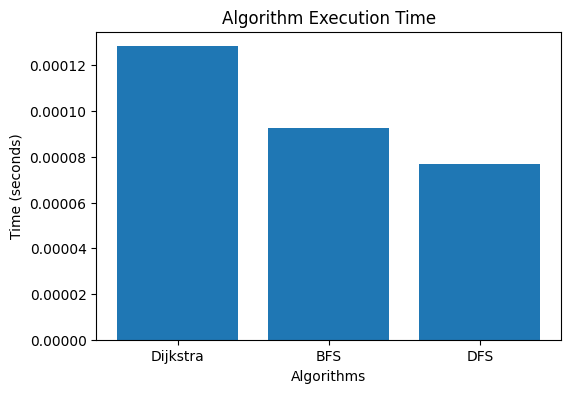

In [ ]:
import matplotlib.pyplot as plt

algorithms = ["Dijkstra","BFS","DFS"]

times = [
    dijkstra_time,
    bfs_time,
    dfs_time
]

plt.figure(figsize=(6,4))

plt.bar(
    algorithms,
    times
)

plt.title(
    "Algorithm Execution Time"
)

plt.xlabel(
    "Algorithms"
)

plt.ylabel(
    "Time (seconds)"
)

plt.show()

In [ ]:
plt.savefig(
    "graph1_execution_time.png"
)

plt.savefig(
    "graph2_distance.png"
)

plt.savefig(
    "graph3_connectivity.png"
)

<Figure size 640x480 with 0 Axes>

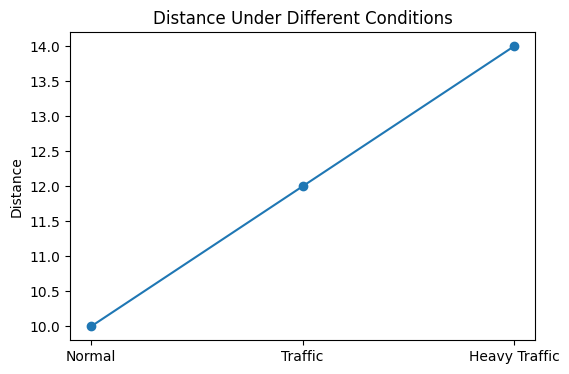

In [ ]:
distances = [
    distance,
    distance * 1.2,
    distance * 1.4
]

labels = [
    "Normal",
    "Traffic",
    "Heavy Traffic"
]

plt.figure(figsize=(6,4))

plt.plot(
    labels,
    distances,
    marker="o"
)

plt.title(
    "Distance Under Different Conditions"
)

plt.ylabel(
    "Distance"
)

plt.show()

In [ ]:
plt.savefig(
    "graph1_execution_time.png"
)

plt.savefig(
    "graph2_distance.png"
)

plt.savefig(
    "graph3_connectivity.png"
)

<Figure size 640x480 with 0 Axes>

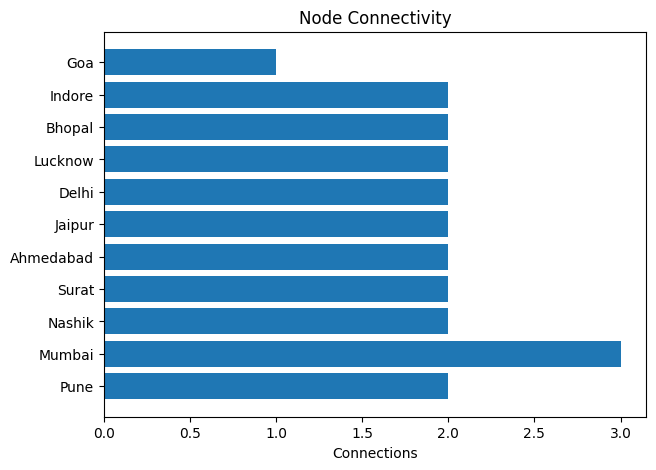

In [ ]:
connections = []

cities = []

for city in graph:

    cities.append(city)

    connections.append(
        len(graph[city])
    )

plt.figure(figsize=(7,5))

plt.barh(
    cities,
    connections
)

plt.title(
    "Node Connectivity"
)

plt.xlabel(
    "Connections"
)

plt.show()

In [ ]:
plt.savefig(
    "graph1_execution_time.png"
)

plt.savefig(
    "graph2_distance.png"
)

plt.savefig(
    "graph3_connectivity.png"
)


<Figure size 640x480 with 0 Axes>

In [ ]:
import os

os.makedirs(
    "outputs",
    exist_ok=True
)

In [ ]:
import shutil

shutil.move(
    "route_results.csv",
    "outputs/route_results.csv"
)

'outputs/route_results.csv'

In [ ]:
requirements = """

networkx
matplotlib
pandas

"""

with open(
    "requirements.txt",
    "w"
) as f:

    f.write(
        requirements
    )

print(
    "requirements.txt created"
)

requirements.txt created
